In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

In [2]:
train_data=pd.read_csv('train_data.csv')
train_data

,loan_id,origination_date,maturity_date,maturity_months,sector,loan_type,collateral,initial_rating,credit_score,ead,...,Telecom,Utilities,bond,lease,mortgage,revolving,term_loan,partially_secured,secured,unsecured
0,L008633,2015-01-01,2016-01-01,0.000000,Consumer,term_loan,unsecured,0.714286,0.700000,-0.289402,...,0,0,0,0,0,0,1,0,0,1
1,L009184,2015-01-01,2016-01-01,0.000000,Industrials,bond,unsecured,1.000000,0.805455,-0.377311,...,0,0,1,0,0,0,0,0,0,1
2,L010332,2015-01-01,2016-01-01,0.000000,Retail,lease,secured,0.714286,0.794545,0.814112,...,0,0,0,1,0,0,0,0,1,0
3,L011575,2015-01-01,2016-01-01,0.000000,Real_Estate,revolving,partially_secured,0.571429,0.934545,-0.091036,...,0,0,0,0,0,1,0,1,0,0
4,L014402,2015-01-01,2016-01-01,0.000000,Energy,bond,partially_secured,0.571429,0.838182,-0.063589,...,0,0,1,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34995,L015462,2021-04-01,2024-12-31,0.444444,Consumer,mortgage,secured,0.571429,0.674545,-0.464890,...,0,0,0,0,1,0,0,0,1,0
34996,L015508,2021-04-01,2024-12-31,0.333333,Utilities,mortgage,unsecured,0.428571,0.821818,-0.155166,...,0,1,0,0,1,0,0,0,0,1
34997,L015595,2021-04-01,2024-12-31,1.000000,Technology,revolving,unsecured,0.571429,0.803636,-0.238896,...,0,0,0,0,0,1,0,0,0,1
34998,L015659,2021-04-01,2024-12-31,0.666667,Real_Estate,term_loan,secured,0.857143,0.838182,-0.228936,...,0,0,0,0,0,0,1,0,1,0


In [3]:
test_data=pd.read_csv('test_data.csv')
test_data

,loan_id,origination_date,maturity_date,maturity_months,sector,loan_type,collateral,initial_rating,credit_score,ead,...,Telecom,Utilities,bond,lease,mortgage,revolving,term_loan,partially_secured,secured,unsecured
0,L016040,2021-04-01,2024-12-31,0.333333,Energy,bond,partially_secured,0.142857,0.687273,-0.426455,...,0,0,1,0,0,0,0,1,0,0
1,L016223,2021-04-01,2024-12-31,0.444444,Financials,revolving,partially_secured,0.285714,0.807273,-0.349716,...,0,0,0,0,0,1,0,1,0,0
2,L016308,2021-04-01,2024-12-31,1.000000,Retail,term_loan,unsecured,0.428571,0.647273,0.079292,...,0,0,0,0,0,0,1,0,0,1
3,L016659,2021-04-01,2024-12-31,0.444444,Industrials,mortgage,secured,0.285714,0.601818,-0.382590,...,0,0,0,0,1,0,0,0,1,0
4,L016683,2021-04-01,2024-12-31,1.000000,Real_Estate,term_loan,unsecured,0.428571,0.707273,1.054665,...,0,0,0,0,0,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,L049222,2023-12-01,2024-12-31,0.666667,Financials,mortgage,partially_secured,0.571429,0.740000,-0.435100,...,0,0,0,0,1,0,0,1,0,0
14996,L049376,2023-12-01,2024-12-31,1.000000,Telecom,mortgage,secured,0.571429,0.763636,-0.385395,...,1,0,0,0,1,0,0,0,1,0
14997,L049468,2023-12-01,2024-12-31,0.666667,Energy,term_loan,unsecured,0.428571,0.758182,-0.064488,...,0,0,0,0,0,0,1,0,0,1
14998,L049469,2023-12-01,2024-12-31,1.000000,Retail,lease,secured,0.857143,0.910909,-0.259069,...,0,0,0,1,0,0,0,0,1,0


In [4]:
train_stat=pd.read_csv('train_stat.csv')
train_stat

,origination_date,maturity_date,maturity_months,credit_score,ead,coupon_rate,leverage,interest_coverage,debt_to_equity,pd_annual,lgd,el,unexpected_loss,rwa,defaulted,default_date,survival_months,recovery_rate,loss_given_default
0,35000,35000,35000.000000,35000.000000,3.500000e+04,35000.000000,35000.000000,35000.000000,35000.000000,35000.000000,35000.000000,3.500000e+04,3.500000e+04,3.500000e+04,35000.000000,5753,35000.000000,5753.000000,5.753000e+03
1,2018-02-06 08:17:54.651428608,2022-03-26 11:27:34.765714176,54.014743,715.089686,3.308804e+06,2.931451,6.904236,3.763323,2.086235,0.022912,0.546819,4.007181e+04,1.850387e+05,5.309515e+05,0.164371,2020-06-15 02:17:10.001738240,48.303371,0.455569,1.753435e+06
2,2015-01-01 00:00:00,2016-01-01 00:00:00,12.000000,518.000000,5.000000e+04,1.000000,0.500000,0.500000,0.100000,0.000158,0.091800,3.600000e+00,2.735300e+02,4.765000e+01,0.000000,2015-02-01 00:00:00,1.000000,0.020000,1.433000e+04
3,2016-07-01 00:00:00,2020-07-01 00:00:00,36.000000,679.000000,5.504071e+05,2.483000,4.050000,2.370000,1.030000,0.001295,0.443400,7.984225e+02,1.739675e+04,1.057908e+04,0.000000,2020-04-01 00:00:00,35.000000,0.353700,2.899526e+05
4,2018-02-01 00:00:00,2022-06-01 00:00:00,48.000000,715.000000,1.396801e+06,3.010000,6.080000,3.310000,1.650000,0.002806,0.544900,3.631560e+03,5.260387e+04,4.811816e+04,0.000000,2020-05-01 00:00:00,48.000000,0.455700,7.219356e+05
5,2019-09-01 00:00:00,2024-05-01 00:00:00,60.000000,750.000000,3.424126e+06,3.458000,9.050000,4.650000,2.630000,0.016640,0.647400,1.893992e+04,1.579063e+05,2.509540e+05,0.000000,2020-06-01 00:00:00,60.000000,0.561500,1.766335e+06
6,2021-04-01 00:00:00,2024-12-31 00:00:00,120.000000,850.000000,3.611778e+08,5.896000,15.000000,20.000000,10.000000,0.242523,0.980000,6.411410e+06,2.239212e+07,8.495118e+07,1.000000,2030-12-01 00:00:00,120.000000,0.854500,1.113264e+08
7,NaN,NaN,26.719180,50.841787,6.723379e+06,0.819725,3.683419,2.009622,1.564232,0.041357,0.144888,1.686148e+05,5.162670e+05,2.234146e+06,0.370618,NaN,26.877033,0.145196,3.807581e+06


In [5]:
sector_col=['Energy', 'Telecom', 'Consumer', 'Financials', 'Industrials', 'Healthcare', 'Technology', 'Utilities', 'Retail', 'Real_Estate']
loan_type_col=['term_loan', 'mortgage', 'revolving', 'bond', 'lease']
collateral_col=['secured', 'unsecured', 'partially_secured']

dummy_backward=[sector_col, loan_type_col, collateral_col]

#catagorize feature column
input_col=['maturity_months','initial_rating','credit_score','ead','coupon_rate','leverage','interest_coverage','debt_to_equity']+sum(dummy_backward,[])  #dummy_col
cal_input_col=['pd_annual','lgd','el','unexpected_loss','rwa']
output_col=['defaulted','survival_months']
cal_output_col=['recovery_rate','loss_given_default']

input_all=input_col+cal_input_col
output_all=output_col+cal_output_col

In [6]:
display(np.sum(train_data['defaulted']))
display(len(train_data))
display(np.sum(train_data['defaulted'])/len(train_data))

display(np.sum(test_data['defaulted']))
display(len(test_data))
display(np.sum(test_data['defaulted'])/len(test_data))

np.int64(5753)

35000

np.float64(0.16437142857142858)

np.int64(1197)

15000

np.float64(0.0798)

# Logistic Regression

## Using all input feature

In [7]:
from sklearn.linear_model import LogisticRegression
log_model2 = LogisticRegression()
log_model2.fit(train_data[input_all],train_data['defaulted']) #exclude calculated columns

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [8]:
train_predict2=log_model2.predict(train_data[input_all])
log_model2.score(train_data[input_all],train_data['defaulted'])

0.8491714285714286

In [9]:
test_predict2=log_model2.predict(test_data[input_all])
log_model2.score(test_data[input_all],test_data['defaulted'])

0.9189333333333334

In [10]:
log_model2.coef_[0]

array([ 1.65408376e+00, -9.86274166e-01, -6.14442061e-01, -5.21118405e-02,
        2.31420821e-01, -1.59461597e-02, -4.38532912e-02, -1.93358553e-03,
       -5.34145450e-02, -7.55162096e-02, -6.10704576e-02,  3.83562234e-05,
       -5.33616791e-02, -1.98456157e-01, -1.65948018e-01, -1.17095712e-01,
       -9.25382109e-02, -9.66542634e-02, -1.68616513e-01, -1.65965486e-01,
       -1.65167667e-01, -2.90426274e-01, -1.23840957e-01, -3.00653217e-01,
       -3.20925489e-01, -2.92438190e-01,  4.51217066e-01, -1.42722795e-02,
       -3.78700127e-02,  1.17969639e-01, -3.78701705e-02])

In [11]:
log_model2.intercept_

array([-0.95671701])

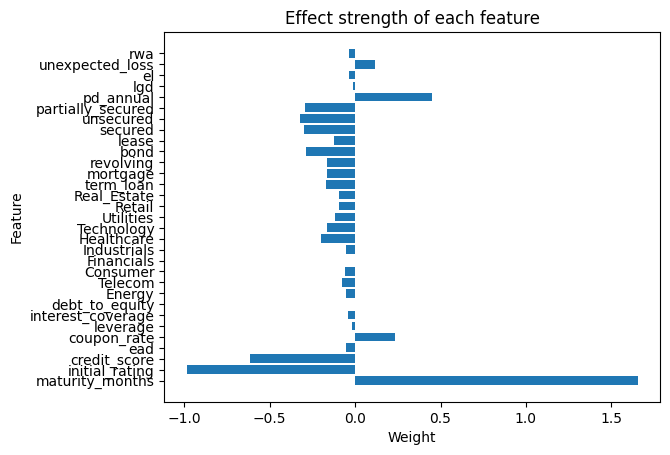

In [12]:
plt.figure()
#plt.barh(input_all+['intercept'], np.concatenate((log_model2.coef_[0],log_model2.intercept_)))
plt.barh(input_all, log_model2.coef_[0])
plt.title('Effect strength of each feature')
plt.xlabel('Weight')
plt.ylabel('Feature')
plt.show()

In [13]:
weight=log_model2.coef_[0]
abs_weight=np.abs(weight)
sort_idx=np.argsort(abs_weight)
sort_idx

array([11,  7, 27,  5, 28, 30,  6,  3, 12,  8, 10,  9, 16, 17, 15, 29, 22,
       20, 14, 19, 18, 13,  4, 21, 25, 23, 24, 26,  2,  1,  0])

In [14]:
sort_idx[::-1]

array([ 0,  1,  2, 26, 24, 23, 25, 21,  4, 13, 18, 19, 14, 20, 22, 29, 15,
       17, 16,  9, 10,  8, 12,  3,  6, 30, 28,  5, 27,  7, 11])

In [15]:
bar_color=['r'*int(weight[i]>0)+'b'*int(weight[i]<=0) for i in sort_idx]

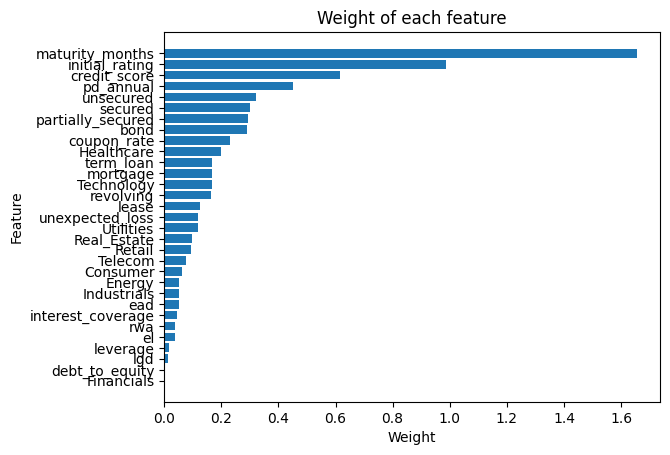

In [16]:
plt.figure()
#plt.barh(input_all+['intercept'], np.concatenate((log_model2.coef_[0],log_model2.intercept_)))
plt.barh([ input_all[i] for i in sort_idx], abs_weight[sort_idx]) #, color=bar_color
plt.title('Weight of each feature')
plt.xlabel('Weight')
plt.ylabel('Feature')
plt.show()

In [17]:
confusion_matrix(train_data['defaulted'],train_predict2) #input : y_true, y_pred
#[[true negative, false positive],
#  [false negative, true positive]]

array([[28485,   762],
       [ 4517,  1236]])

In [18]:
train_true=np.array(train_data['defaulted'])
train_true

array([0, 0, 0, ..., 0, 0, 0], shape=(35000,))

In [19]:
train_predict2

array([0, 0, 0, ..., 0, 0, 0], shape=(35000,))

In [20]:
np.sum(train_true==train_predict2)

np.int64(29721)

In [21]:
print(classification_report(train_data['defaulted'],train_predict2))

              precision    recall  f1-score   support

           0       0.86      0.97      0.92     29247
           1       0.62      0.21      0.32      5753

    accuracy                           0.85     35000
   macro avg       0.74      0.59      0.62     35000
weighted avg       0.82      0.85      0.82     35000



## Evaluation

In [22]:
dom_input = [ input_all[i] for i in sort_idx[::-1]]
dom_input

['maturity_months',
 'initial_rating',
 'credit_score',
 'pd_annual',
 'unsecured',
 'secured',
 'partially_secured',
 'bond',
 'coupon_rate',
 'Healthcare',
 'term_loan',
 'mortgage',
 'Technology',
 'revolving',
 'lease',
 'unexpected_loss',
 'Utilities',
 'Real_Estate',
 'Retail',
 'Telecom',
 'Consumer',
 'Energy',
 'Industrials',
 'ead',
 'interest_coverage',
 'rwa',
 'el',
 'leverage',
 'lgd',
 'debt_to_equity',
 'Financials']

In [23]:
N = len(dom_input)
all_model = []
train_cost = []
test_cost = []

train_f1 = []
test_f1 = []

train_p = []
test_p = []

train_r = []
test_r = []

for i in range(N):
    dom_input_temp = dom_input[:N-i]

    log_model_temp = LogisticRegression()
    log_model_temp.fit(train_data[dom_input_temp],train_data['defaulted'])
    all_model.append(log_model_temp)

    train_predict_temp=log_model_temp.predict(train_data[dom_input_temp]) #input_all
    train_cost.append( log_model_temp.score(train_data[dom_input_temp],train_data['defaulted']) ) #dom_input_temp

    test_predict_temp=log_model_temp.predict(test_data[dom_input_temp]) #
    test_cost.append( log_model_temp.score(test_data[dom_input_temp],test_data['defaulted']) ) #dom_input_temp

    train_confM=confusion_matrix(train_data['defaulted'],train_predict_temp)
    train_f1.append(2*train_confM[1,1]/(2*train_confM[1,1]+train_confM[1,0]+train_confM[0,1]))
    train_p.append(train_confM[1,1]/(train_confM[1,1]+train_confM[0,1]))
    train_r.append(train_confM[1,1]/(train_confM[1,1]+train_confM[1,0]))

    test_confM=confusion_matrix(test_data['defaulted'],test_predict_temp)
    test_f1.append(2*test_confM[1,1]/(2*test_confM[1,1]+test_confM[1,0]+test_confM[0,1]))
    test_p.append(test_confM[1,1]/(test_confM[1,1]+test_confM[0,1]))
    test_r.append(test_confM[1,1]/(test_confM[1,1]+test_confM[1,0]))

C:\Users\ASUS\AppData\Local\Temp\ipykernel_15812\681372337.py:30: RuntimeWarning: invalid value encountered in scalar divide
  train_p.append(train_confM[1,1]/(train_confM[1,1]+train_confM[0,1]))
C:\Users\ASUS\AppData\Local\Temp\ipykernel_15812\681372337.py:35: RuntimeWarning: invalid value encountered in scalar divide
  test_p.append(test_confM[1,1]/(test_confM[1,1]+test_confM[0,1]))


In [24]:
dom_input[:N]

['maturity_months',
 'initial_rating',
 'credit_score',
 'pd_annual',
 'unsecured',
 'secured',
 'partially_secured',
 'bond',
 'coupon_rate',
 'Healthcare',
 'term_loan',
 'mortgage',
 'Technology',
 'revolving',
 'lease',
 'unexpected_loss',
 'Utilities',
 'Real_Estate',
 'Retail',
 'Telecom',
 'Consumer',
 'Energy',
 'Industrials',
 'ead',
 'interest_coverage',
 'rwa',
 'el',
 'leverage',
 'lgd',
 'debt_to_equity',
 'Financials']

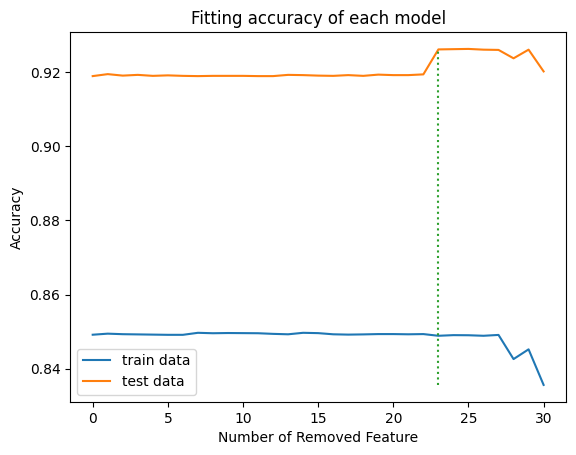

In [25]:
plt.figure()
plt.plot(train_cost, label='train data')
plt.plot(test_cost, label='test data')
plt.plot([23,23],[np.min(train_cost), np.max(test_cost)], linestyle=':')
plt.title('Fitting accuracy of each model')
plt.xlabel('Number of Removed Feature')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [26]:
test_cost[20:]

[0.9192,
 0.9192,
 0.9194,
 0.9261333333333334,
 0.9262,
 0.9262666666666667,
 0.9260666666666667,
 0.926,
 0.9237333333333333,
 0.9260666666666667,
 0.9202]

In [27]:
dom_input[:N-20] # conclusion : all we need are maturity_months, initial_rating, credit_score, pd_anual, type of collateral(unsecure>secure>partially_secured) 

['maturity_months',
 'initial_rating',
 'credit_score',
 'pd_annual',
 'unsecured',
 'secured',
 'partially_secured',
 'bond',
 'coupon_rate',
 'Healthcare',
 'term_loan']

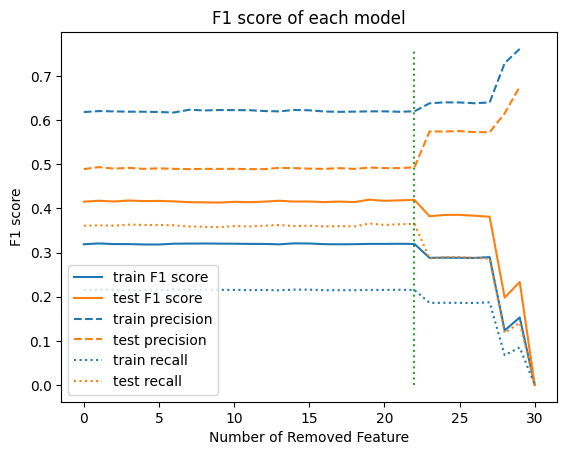

In [28]:
plt.figure()
plt.plot(train_f1, label='train F1 score', c='C0')
plt.plot(test_f1, label='test F1 score', c='C1')
plt.plot(train_p, label='train precision', c='C0', linestyle='--')
plt.plot(test_p, label='test precision', c='C1', linestyle='--')
plt.plot(train_r, label='train recall', c='C0', linestyle=':')
plt.plot(test_r, label='test recall', c='C1', linestyle=':')
#plt.plot([22,22],[np.min(train_f1), np.max(test_f1)], linestyle=':', c='C2')
plt.plot([22,22],[0, 0.76], linestyle=':', c='C2')
plt.title('F1 score of each model')
plt.xlabel('Number of Removed Feature')
plt.ylabel('F1 score')
plt.legend()
plt.show()

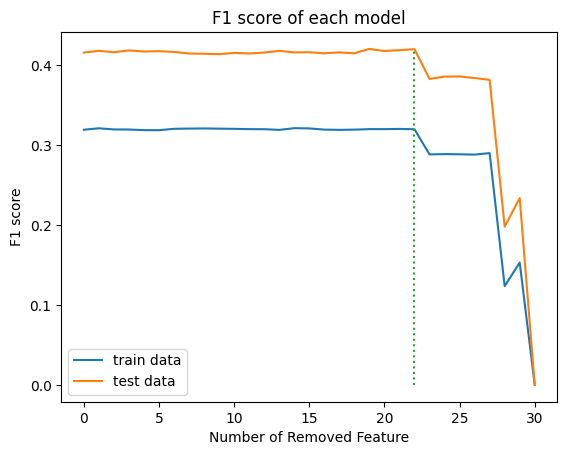

In [29]:
plt.figure()
plt.plot(train_f1, label='train data')
plt.plot(test_f1, label='test data')
plt.plot([22,22],[np.min(train_f1), np.max(test_f1)], linestyle=':')
plt.title('F1 score of each model')
plt.xlabel('Number of Removed Feature')
plt.ylabel('F1 score')
plt.legend()
plt.show()

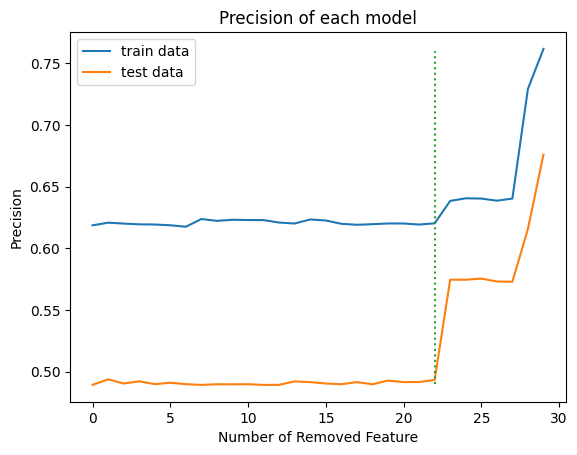

In [30]:
plt.figure()
plt.plot(train_p, label='train data')
plt.plot(test_p, label='test data')
plt.plot([22,22],[0.49, 0.76], linestyle=':')
plt.title('Precision of each model')
plt.xlabel('Number of Removed Feature')
plt.ylabel('Precision')
plt.legend()
plt.show()

In [31]:
[np.min(test_p), np.max(train_p)]

[np.float64(nan), np.float64(nan)]

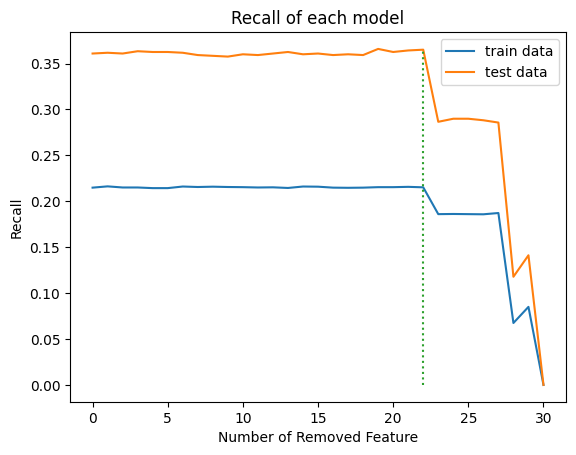

In [32]:
plt.figure()
plt.plot(train_r, label='train data')
plt.plot(test_r, label='test data')
plt.plot([22,22],[np.min(test_r), np.max(test_r)], linestyle=':')
plt.title('Recall of each model')
plt.xlabel('Number of Removed Feature')
plt.ylabel('Recall')
plt.legend()
plt.show()

In [40]:
display(np.array(test_p[20:]))
display(np.array(test_r[20:]))
display(np.array(test_f1[20:]))

array([0.49150623, 0.49154453, 0.49322799, 0.57453936, 0.57450331,
       0.57545605, 0.5730897 , 0.57286432, 0.61572052, 0.676     ,
              nan])

array([0.3625731 , 0.36424394, 0.36507937, 0.28654971, 0.2898914 ,
       0.2898914 , 0.28822055, 0.28571429, 0.11779449, 0.1411863 ,
       0.        ])

array([0.41730769, 0.4184261 , 0.41958713, 0.38238573, 0.38534148,
       0.38555556, 0.38354641, 0.3812709 , 0.19775596, 0.23358673,
       0.        ])

In [39]:
display(np.max(test_p))
display(np.argmax(test_p))

display(np.max(test_r))
display(np.argmax(test_r))

display(np.max(test_f1))
display(np.argmax(test_f1))

np.float64(nan)

np.int64(30)

np.float64(0.3659147869674185)

np.int64(19)

np.float64(0.4199424736337488)

np.int64(19)

## Weight and Intercetp

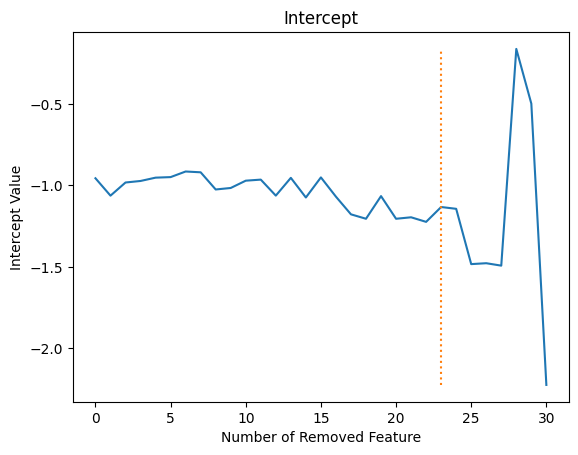

In [33]:
plt.figure()
all_intercept=[all_model[i].intercept_ for i in range(N)]
plt.plot(all_intercept)
plt.plot([23,23],[np.min(all_intercept), np.max(all_intercept)], linestyle=':')
plt.title('Intercept')
plt.xlabel('Number of Removed Feature')
plt.ylabel('Intercept Value')
#plt.legend()
plt.show()

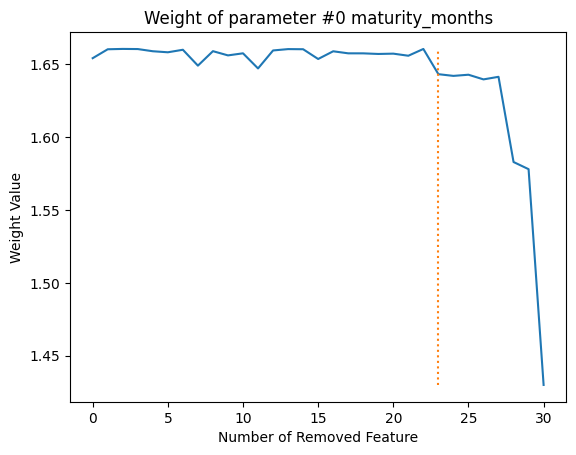

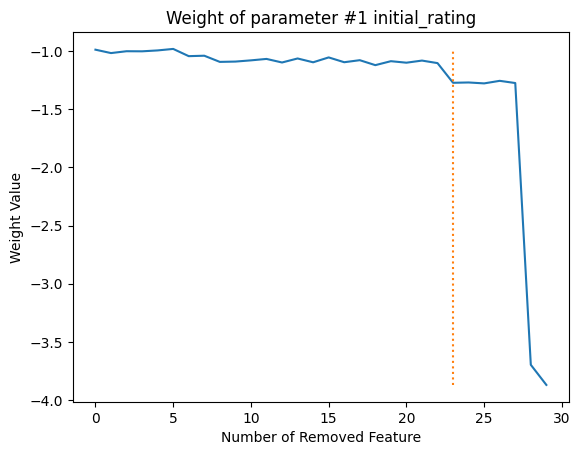

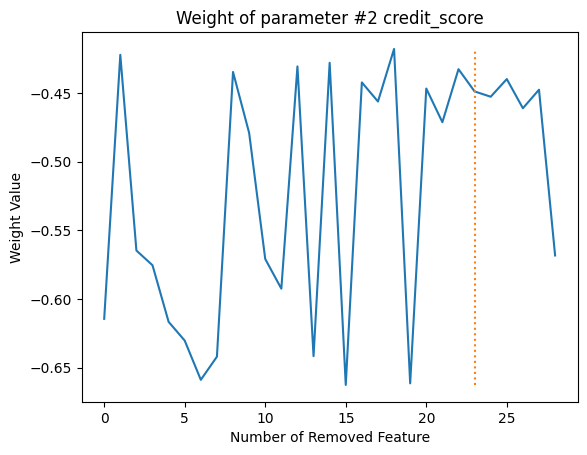

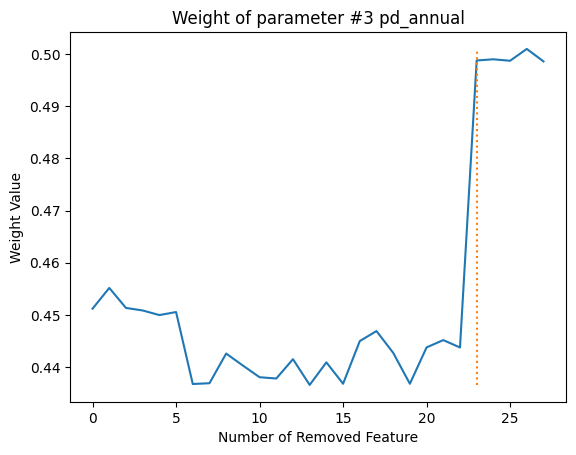

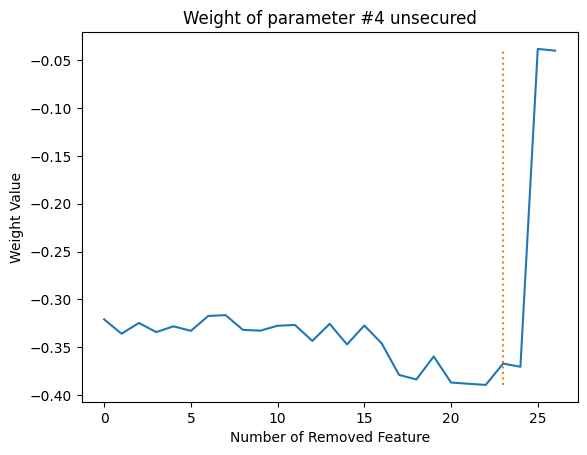

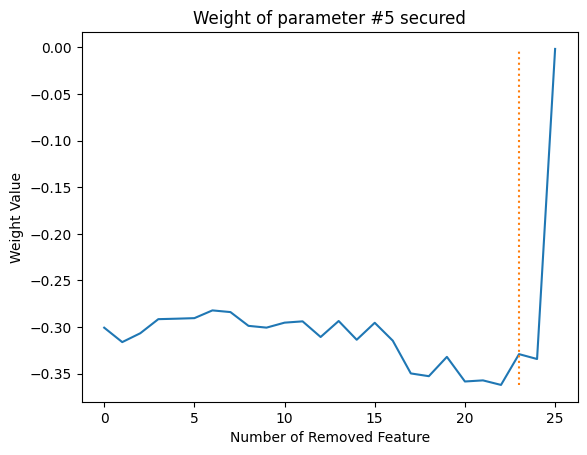

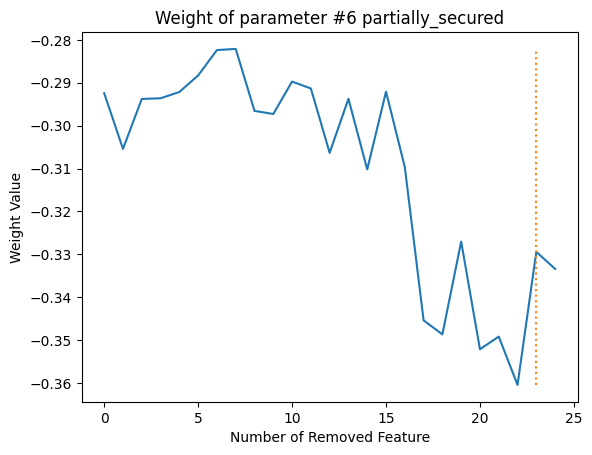

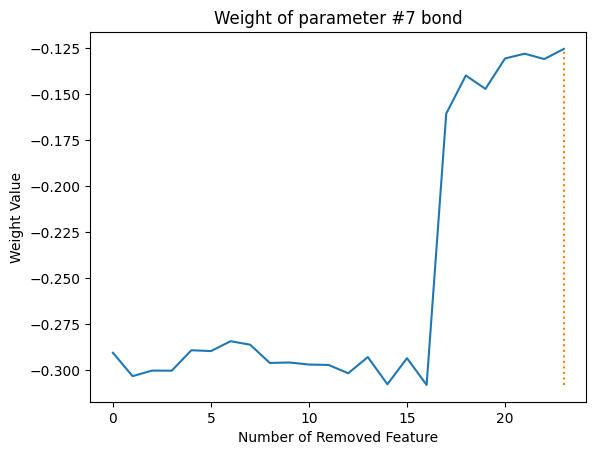

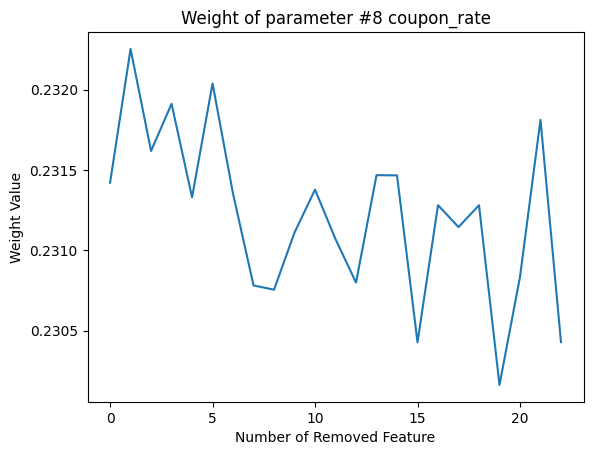

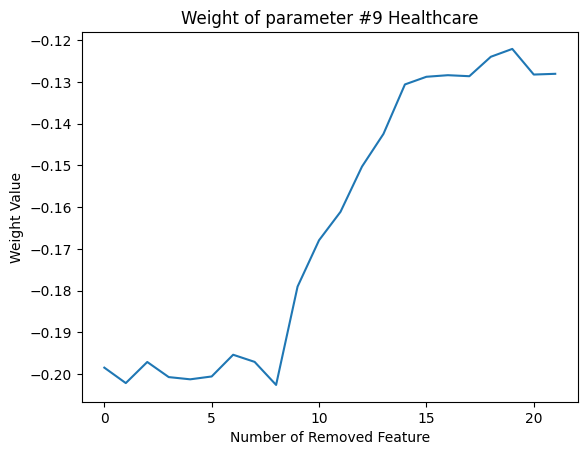

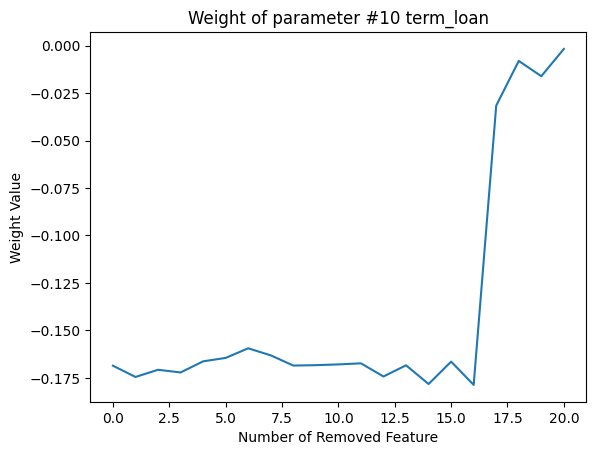

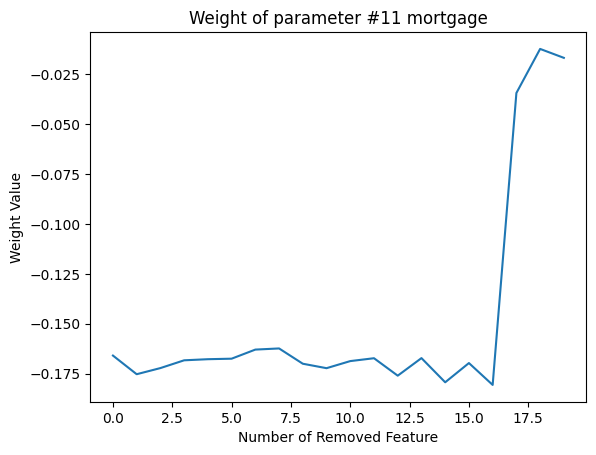

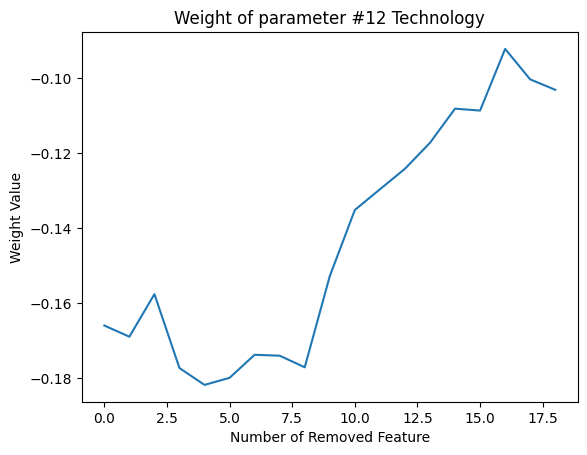

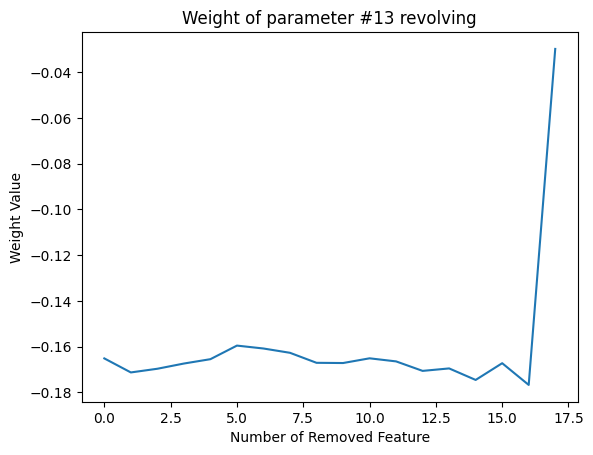

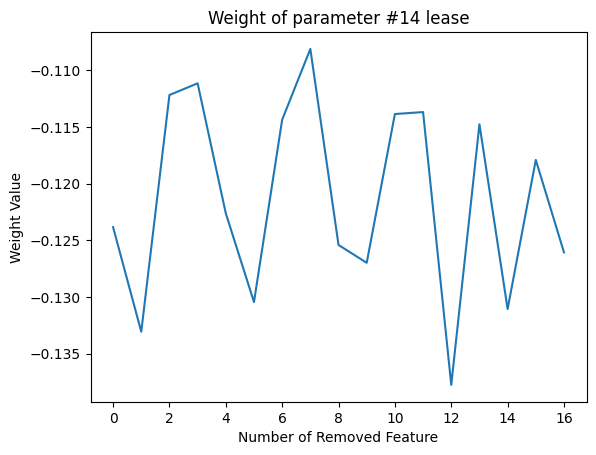

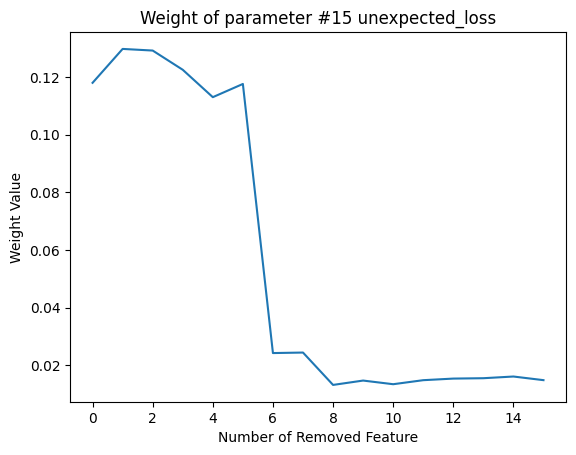

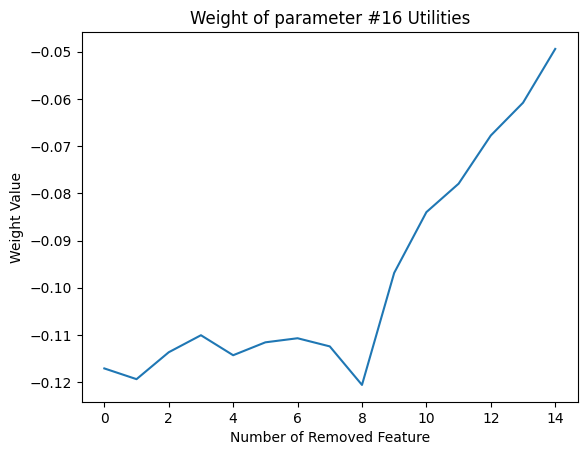

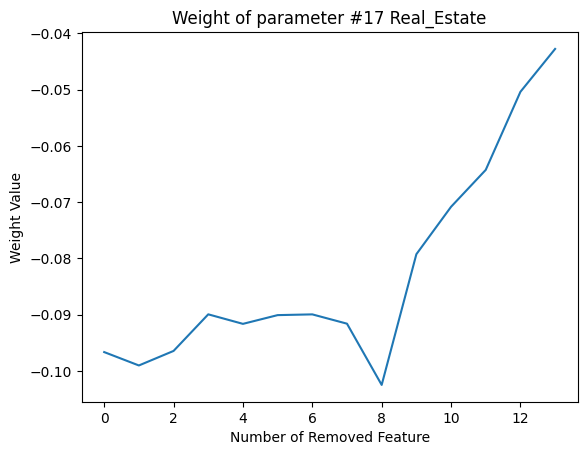

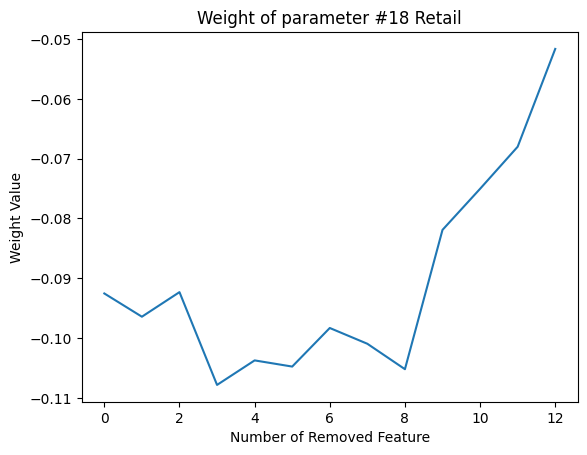

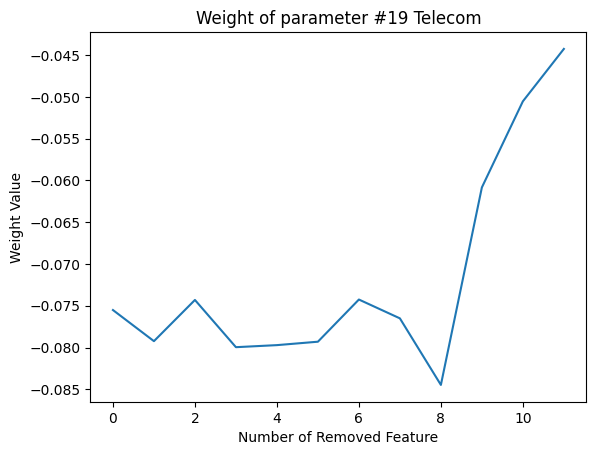

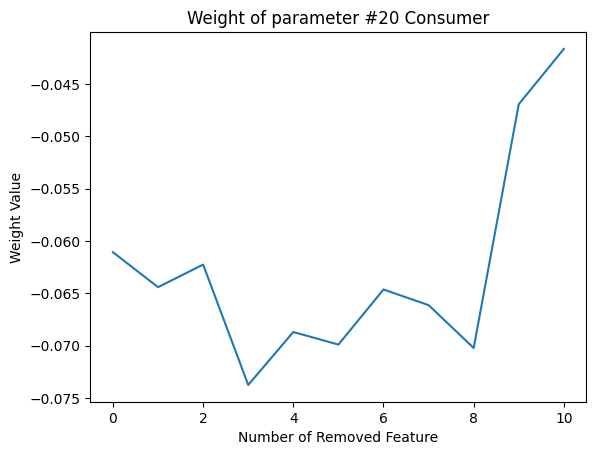

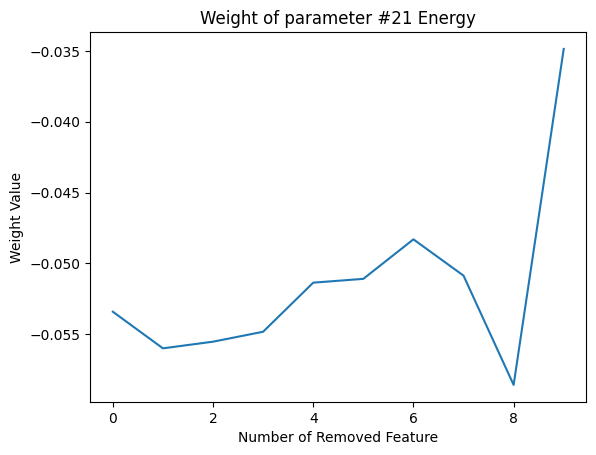

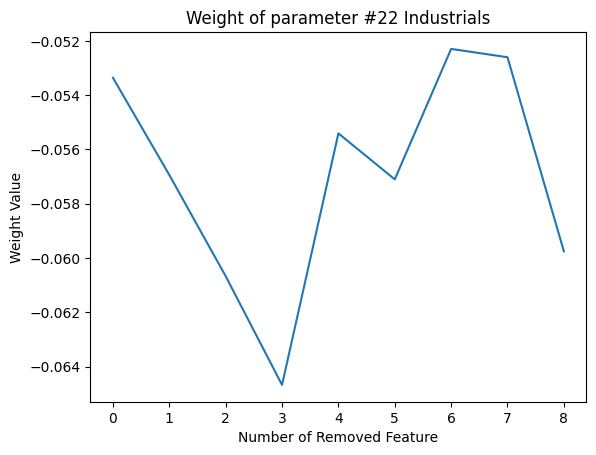

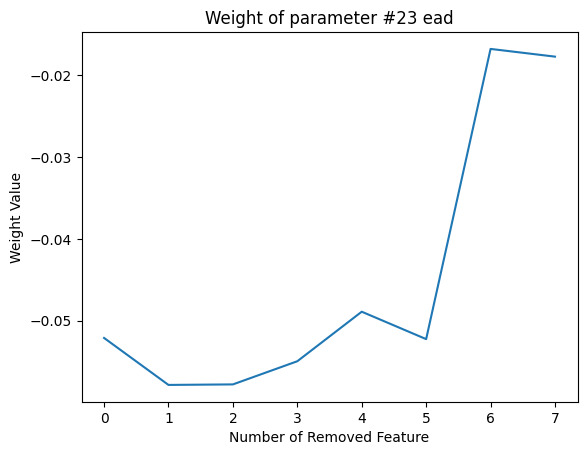

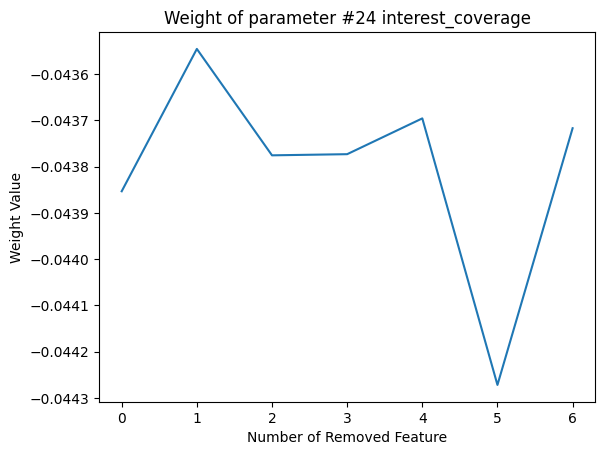

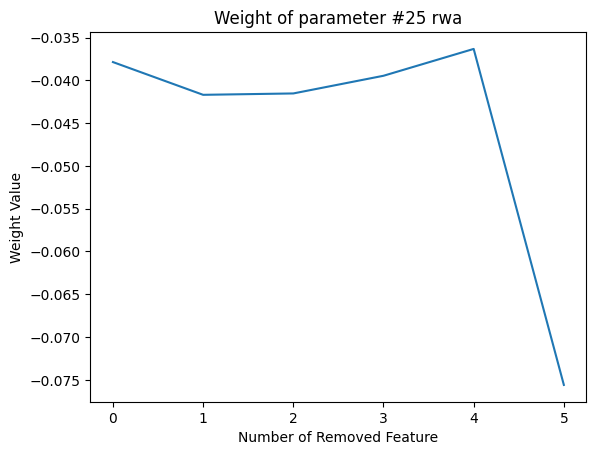

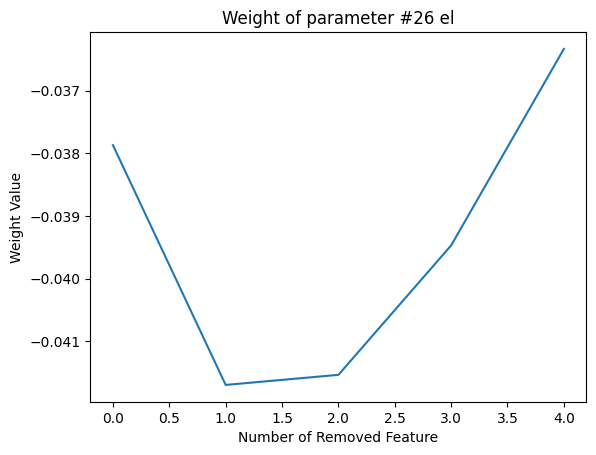

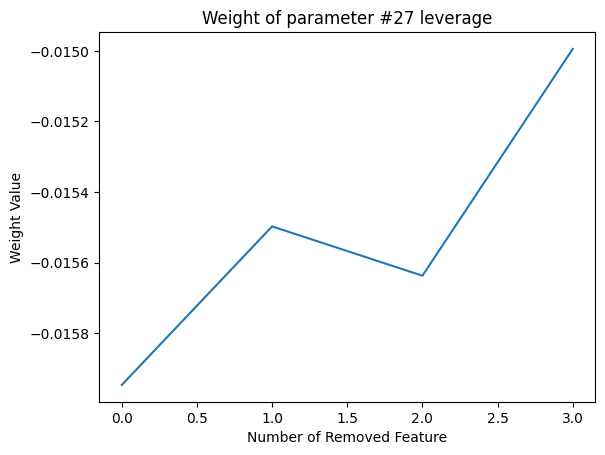

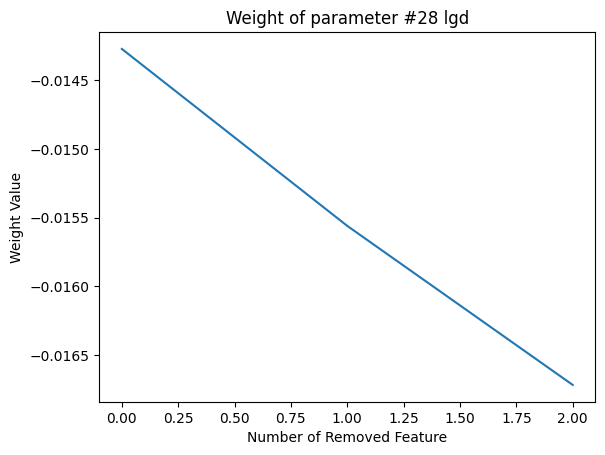

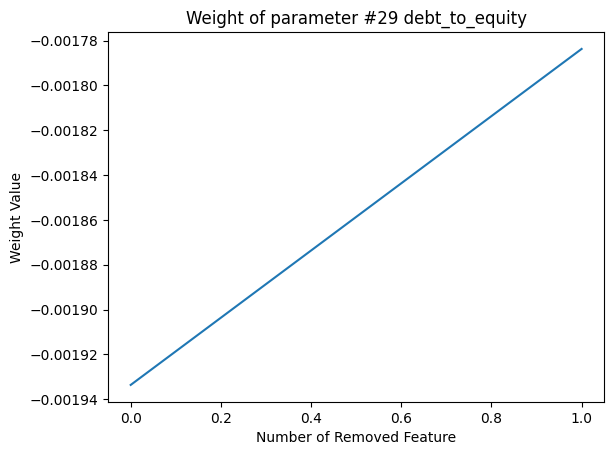

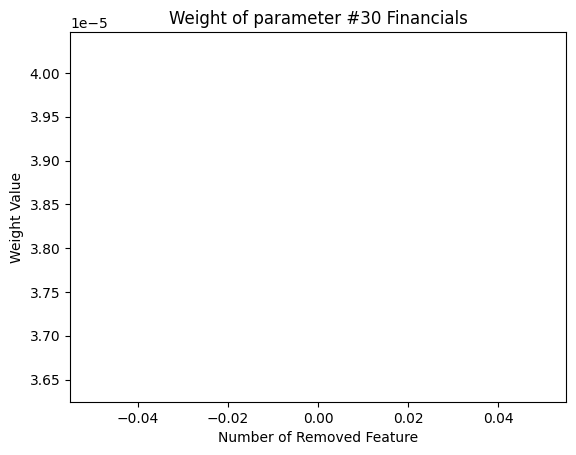

In [34]:
for i in range(N):
    coef_temp=[all_model[j].coef_[0,i] for j in range(N-i)]
    plt.plot(coef_temp)
    if i< N-23:  plt.plot([23,23],[np.min(coef_temp), np.max(coef_temp)], linestyle=':')
    plt.title('Weight of parameter #'+str(i)+ ' '+dom_input[i])
    plt.xlabel('Number of Removed Feature')
    plt.ylabel('Weight Value')
    #plt.legend()
    plt.show()

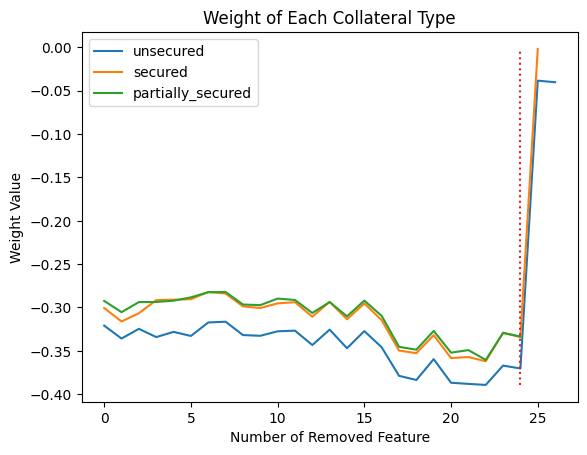

In [35]:
coef_temp_all=[]

plt.figure()
for i in range(N):
    if dom_input[i] in collateral_col:
        coef_temp=[all_model[j].coef_[0,i] for j in range(N-i)]
        plt.plot(coef_temp, label=dom_input[i])
        coef_temp_all.extend(coef_temp)
#plt.plot([24,24],[-0.4, 0], linestyle=':')
plt.plot([24,24],[min(coef_temp_all), max(coef_temp_all)], linestyle=':')
plt.title('Weight of Each Collateral Type')
plt.xlabel('Number of Removed Feature')
plt.ylabel('Weight Value')
plt.legend()
plt.show()

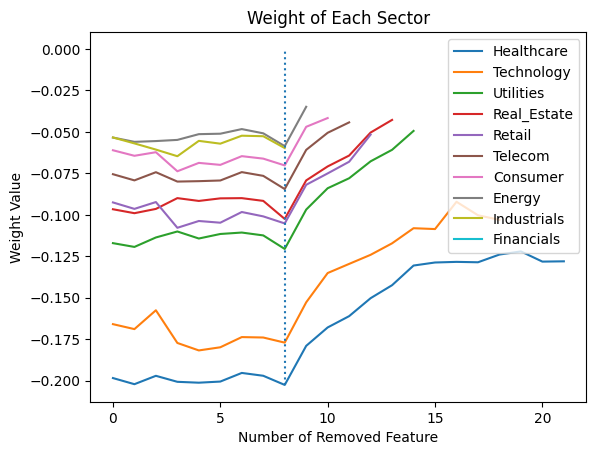

In [36]:
coef_temp_all=[]

plt.figure()
for i in range(N):
    if dom_input[i] in sector_col:
        coef_temp=[all_model[j].coef_[0,i] for j in range(N-i)]
        plt.plot(coef_temp, label=dom_input[i])
        coef_temp_all.extend(coef_temp)
#plt.plot([8,8],[-0.21, -0.03], linestyle=':')
plt.plot([8,8],[min(coef_temp_all), max(coef_temp_all)], linestyle=':')
plt.title('Weight of Each Sector')
plt.xlabel('Number of Removed Feature')
plt.ylabel('Weight Value')
plt.legend()
plt.show()

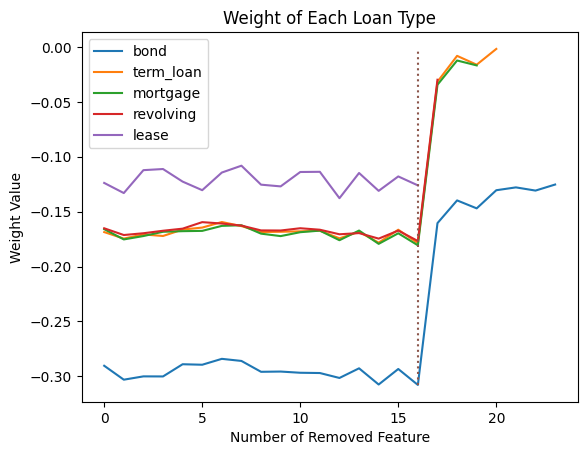

In [37]:
coef_temp_all=[]

plt.figure()
for i in range(N):
    if dom_input[i] in loan_type_col:
        coef_temp=[all_model[j].coef_[0,i] for j in range(N-i)]
        plt.plot(coef_temp, label=dom_input[i])
        coef_temp_all.extend(coef_temp)
#plt.plot([16,16],[0, -0.31], linestyle=':')
plt.plot([16,16],[min(coef_temp_all), max(coef_temp_all)], linestyle=':')
plt.title('Weight of Each Loan Type')
plt.xlabel('Number of Removed Feature')
plt.ylabel('Weight Value')
plt.legend()
plt.show()

## Plot by 2 dominant features